# Data Science Salary Analysis
**Dataset:** [Data Science Job Salaries](https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries)  
**Author:** Matt  
**Goal:** Explore salary trends across roles, experience levels, company sizes, and remote work ratios in the data science field.

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('data')
VISUALS_DIR = Path('visuals')
VISUALS_DIR.mkdir(exist_ok=True)

print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load Data

In [2]:
df = pd.read_csv(DATA_DIR / 'ds_salaries.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (607, 12)


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


## 3. Data Overview & Cleaning

In [3]:
print('=== Column Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Stats ===')
df.describe()

=== Column Types ===
Unnamed: 0            int64
work_year             int64
experience_level        str
employment_type         str
job_title               str
salary                int64
salary_currency         str
salary_in_usd         int64
employee_residence      str
remote_ratio          int64
company_location        str
company_size            str
dtype: object

=== Missing Values ===
Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

=== Basic Stats ===


,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.00,607.00,607.00,607.00,607.00
mean,303.00,"2,021.41","324,000.06","112,297.87",70.92
std,175.37,0.69,"1,544,357.49","70,957.26",40.71
min,0.00,"2,020.00","4,000.00","2,859.00",0.00
25%,151.50,"2,021.00","70,000.00","62,726.00",50.00
50%,303.00,"2,022.00","115,000.00","101,570.00",100.00
75%,454.50,"2,022.00","165,000.00","150,000.00",100.00
max,606.00,"2,022.00","30,400,000.00","600,000.00",100.00


In [4]:
# Map coded values to human-readable labels
experience_map = {'EN': 'Entry', 'MI': 'Mid', 'SE': 'Senior', 'EX': 'Executive'}
employment_map = {'FT': 'Full-Time', 'PT': 'Part-Time', 'CT': 'Contract', 'FL': 'Freelance'}
size_map       = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}

df['experience_level_label'] = df['experience_level'].map(experience_map)
df['employment_type_label']  = df['employment_type'].map(employment_map)
df['company_size_label']     = df['company_size'].map(size_map)

# Ordered category for experience
exp_order = ['Entry', 'Mid', 'Senior', 'Executive']
df['experience_level_label'] = pd.Categorical(
    df['experience_level_label'], categories=exp_order, ordered=True
)

print('Cleaned. Sample:')
df[['job_title', 'experience_level_label', 'salary_in_usd', 'remote_ratio', 'company_size_label']].head(10)

Cleaned. Sample:


,job_title,experience_level_label,salary_in_usd,remote_ratio,company_size_label
0,Data Scientist,Mid,79833,0,Large
1,Machine Learning Scientist,Senior,260000,0,Small
2,Big Data Engineer,Senior,109024,50,Medium
3,Product Data Analyst,Mid,20000,0,Small
4,Machine Learning Engineer,Senior,150000,50,Large
5,Data Analyst,Entry,72000,100,Large
6,Lead Data Scientist,Senior,190000,100,Small
7,Data Scientist,Mid,35735,50,Large
8,Business Data Analyst,Mid,135000,100,Large
9,Lead Data Engineer,Senior,125000,50,Small


## 4. Salary Distribution

/tmp/ipykernel_14011/2505528400.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


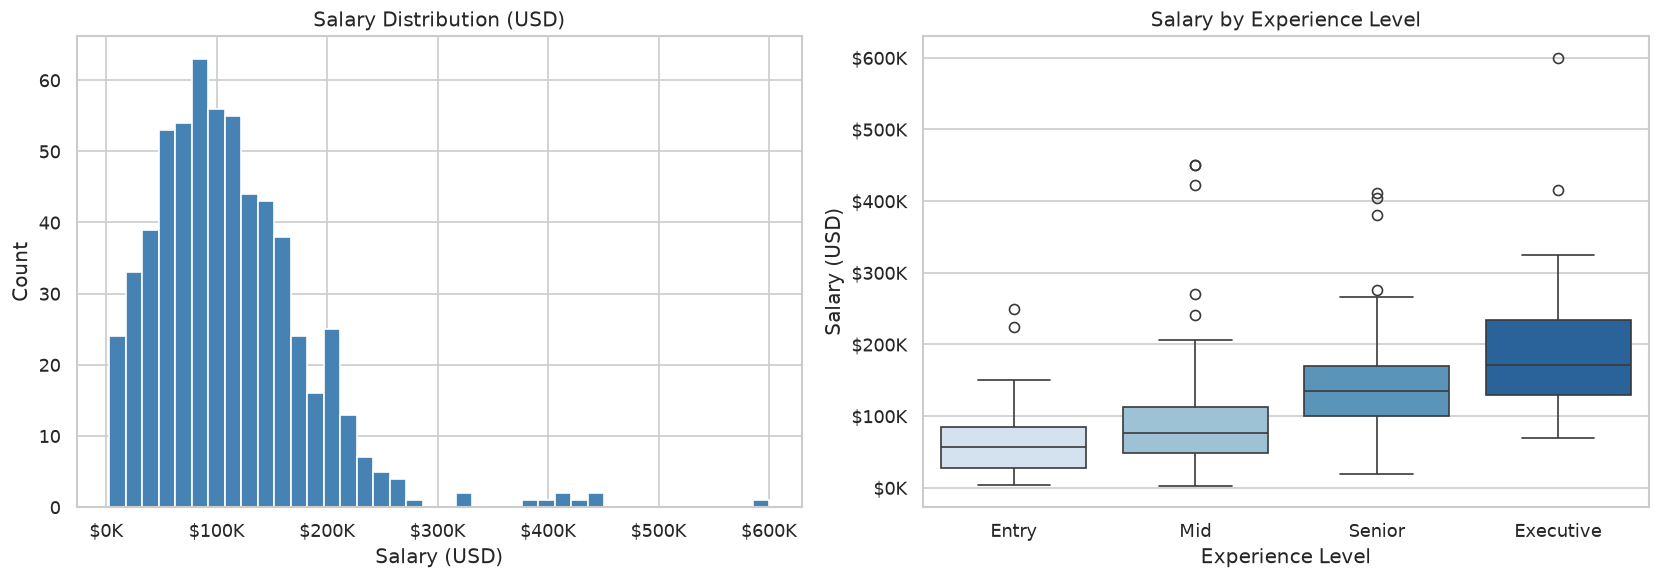

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['salary_in_usd'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Salary Distribution (USD)')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Box plot by experience
sns.boxplot(
    data=df, x='experience_level_label', y='salary_in_usd',
    order=exp_order, ax=axes[1], palette='Blues'
)
axes[1].set_title('Salary by Experience Level')
axes[1].set_xlabel('Experience Level')
axes[1].set_ylabel('Salary (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig(VISUALS_DIR / '01_salary_distribution.png')
plt.show()

## 5. Top Job Titles by Median Salary

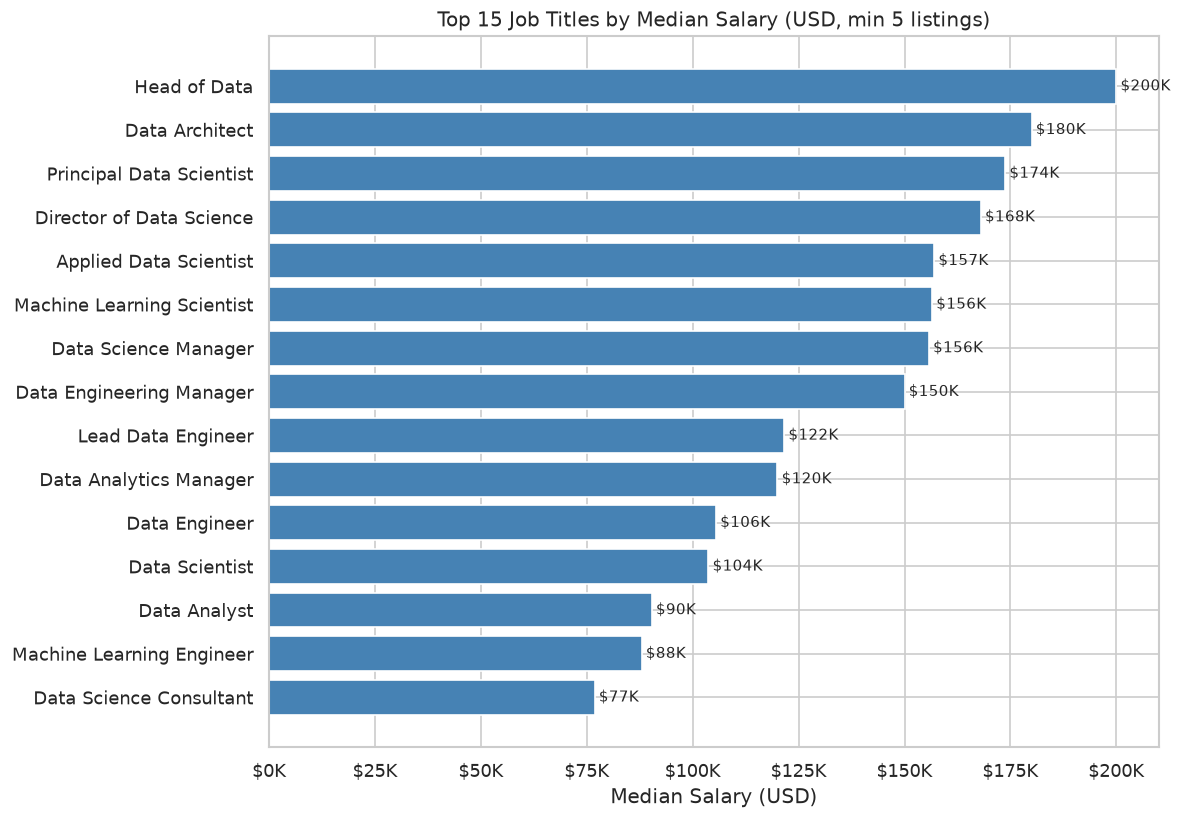

In [6]:
top_titles = (
    df.groupby('job_title')['salary_in_usd']
    .agg(['median', 'count'])
    .query('count >= 5')           # filter low-sample titles
    .sort_values('median', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_titles['job_title'][::-1], top_titles['median'][::-1], color='steelblue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Top 15 Job Titles by Median Salary (USD, min 5 listings)')
ax.set_xlabel('Median Salary (USD)')

# Annotate bars
for bar, val in zip(bars, top_titles['median'][::-1]):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'${val/1000:.0f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(VISUALS_DIR / '02_top_job_titles.png')
plt.show()

## 6. Salary Trends Over Time

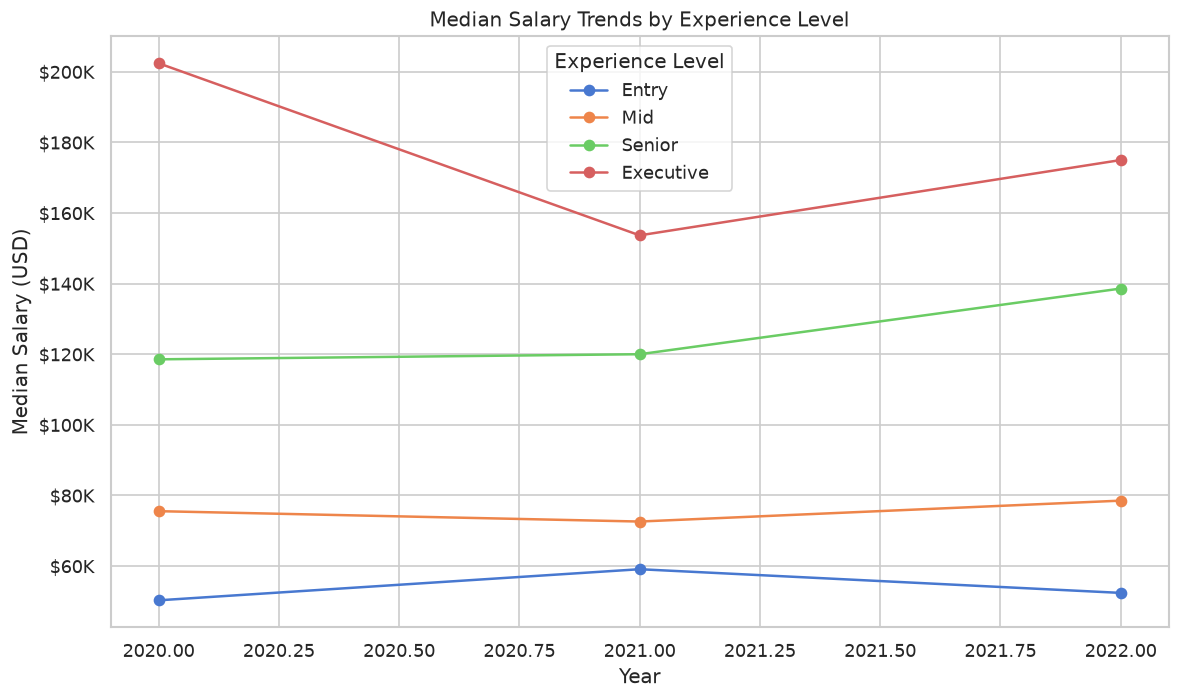

In [7]:
yearly = (
    df.groupby(['work_year', 'experience_level_label'])['salary_in_usd']
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
for level in exp_order:
    subset = yearly[yearly['experience_level_label'] == level]
    ax.plot(subset['work_year'], subset['salary_in_usd'], marker='o', label=level)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Median Salary Trends by Experience Level')
ax.set_xlabel('Year')
ax.set_ylabel('Median Salary (USD)')
ax.legend(title='Experience Level')
plt.tight_layout()
plt.savefig(VISUALS_DIR / '03_salary_trends.png')
plt.show()

## 7. Remote Work vs. Salary

/tmp/ipykernel_14011/692547321.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


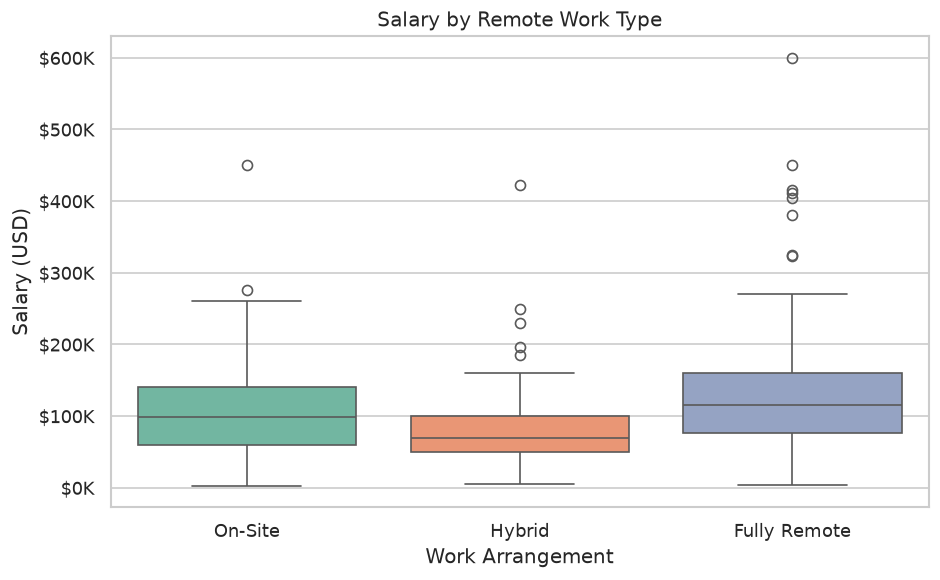

In [8]:
remote_map = {0: 'On-Site', 50: 'Hybrid', 100: 'Fully Remote'}
df['remote_label'] = df['remote_ratio'].map(remote_map)

remote_order = ['On-Site', 'Hybrid', 'Fully Remote']
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df, x='remote_label', y='salary_in_usd',
    order=remote_order, palette='Set2', ax=ax
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Salary by Remote Work Type')
ax.set_xlabel('Work Arrangement')
ax.set_ylabel('Salary (USD)')
plt.tight_layout()
plt.savefig(VISUALS_DIR / '04_remote_vs_salary.png')
plt.show()

## 8. Company Size vs. Salary

/tmp/ipykernel_14011/2396283464.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


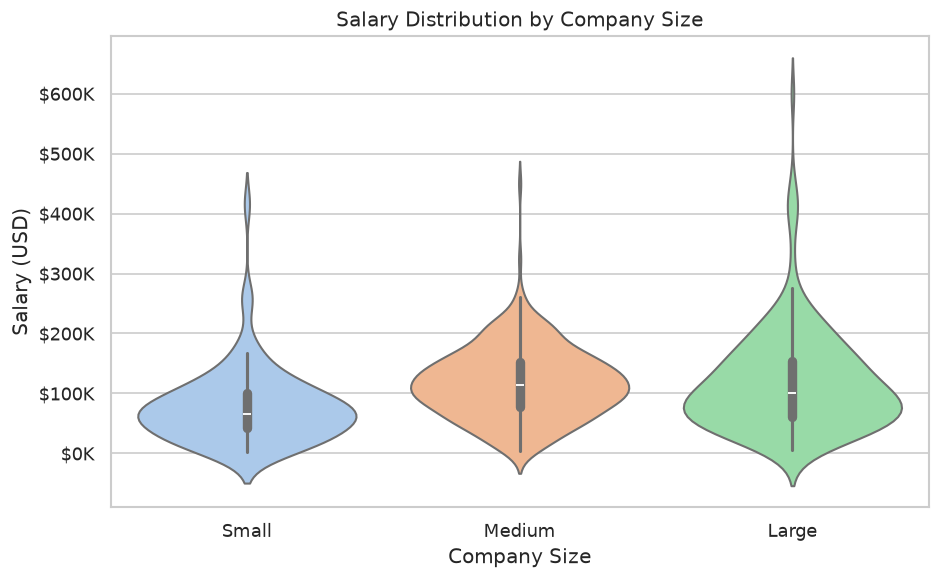

In [9]:
size_order = ['Small', 'Medium', 'Large']
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(
    data=df, x='company_size_label', y='salary_in_usd',
    order=size_order, palette='pastel', ax=ax, inner='box'
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Salary Distribution by Company Size')
ax.set_xlabel('Company Size')
ax.set_ylabel('Salary (USD)')
plt.tight_layout()
plt.savefig(VISUALS_DIR / '05_company_size.png')
plt.show()

## 9. Entry-Level Focus — What Can Matt Expect?

In [10]:
entry = df[df['experience_level_label'] == 'Entry'].copy()

print(f"Entry-level records: {len(entry)}")
print(f"\nMedian salary:  ${entry['salary_in_usd'].median():,.0f}")
print(f"Mean salary:    ${entry['salary_in_usd'].mean():,.0f}")
print(f"25th pct:       ${entry['salary_in_usd'].quantile(0.25):,.0f}")
print(f"75th pct:       ${entry['salary_in_usd'].quantile(0.75):,.0f}")

print('\nTop entry-level titles by count:')
print(entry['job_title'].value_counts().head(10).to_string())

Entry-level records: 88

Median salary:  $56,500
Mean salary:    $61,643
25th pct:       $27,505
75th pct:       $85,426

Top entry-level titles by count:
job_title
Data Scientist               22
Data Analyst                 12
Data Engineer                12
Machine Learning Engineer     9
Data Science Consultant       5
Research Scientist            4
AI Scientist                  4
Big Data Engineer             3
Computer Vision Engineer      3
Business Data Analyst         2


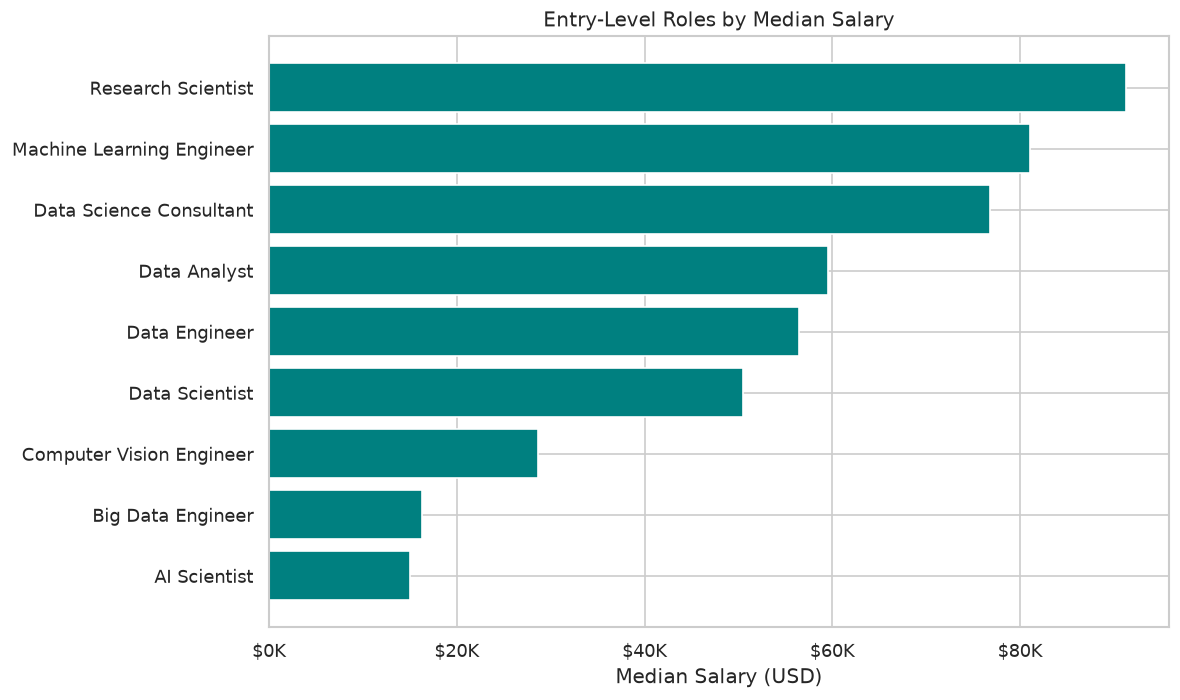

In [11]:
entry_titles = (
    entry.groupby('job_title')['salary_in_usd']
    .agg(['median', 'count'])
    .query('count >= 3')
    .sort_values('median', ascending=False)
    .head(12)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(entry_titles['job_title'][::-1], entry_titles['median'][::-1], color='teal')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Entry-Level Roles by Median Salary')
ax.set_xlabel('Median Salary (USD)')
plt.tight_layout()
plt.savefig(VISUALS_DIR / '06_entry_level_salaries.png')
plt.show()

## 10. Key Takeaways

*(Fill in after running the analysis)*

- **Overall range:** ...
- **Entry-level median:** ...
- **Highest-paying roles:** ...
- **Remote work effect:** ...
- **Company size effect:** ...

---
_Analysis complete. Visuals saved to `/visuals/`._